# One modulation study

- Synthesizer: MinisynthSubtractive
- 4 Parameters:
    - Amplitude (logarithmic)
    - Frequency (logarithmic)
    - Filter Cutoff (logarithmic)
    - Oscillator shape (linear)

Only one parameter is modulated at a time, and the others are static.
Every static parameter is set to 25% 50% or 75% of its range, ranges can be linear or logarithmic.
Modulation is a cosine cycle and it has 5 levels of depth: 10%, 20%, 30%, 40%, 50% of the absolute parameter range, in this way if the parameter is set to 25% and modulated maximum evel it will go from 0% to 50% of its range and a parameter set to 75% and modulated to maximum level will go from 50% to 100% of its range.

The 1620 sounds are 2 seconds long and they cover all the possible combinations of the parameters and modulation levels.
On every sound correlation is calculated on 5 different representations:
- Spectrogram
- CQT
- MFCC
- DAC
- music2latent

extensive plots are provided at the end of the notebook.


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import minisynth
import json
import utils
import h5py
import tqdm

from IPython.display import display, Audio


In [31]:
def linear_map(u, min_val, max_val):
    return min_val + u * (max_val - min_val)

def exp_map(u, min_val, max_val, k=2):
    return min_val + ((np.exp(k * u) - 1) / (np.exp(k) - 1)) * (max_val - min_val)

def load_repr(filename, i):
    with h5py.File(filename, 'r') as f:
        return f[str(i)][:]

In [33]:
synth = minisynth.MiniSynthSubtractive(duration=2.0)

base_values = {}

values = np.linspace(0, 1, 5)

params = synth.get_parameters()
for param_id, param in params.items():
    if param['scale'] == minisynth.Scale.LINEAR:
        base_values[param_id] = linear_map(values, param['range'][0], param['range'][1])
    elif param['scale'] == minisynth.Scale.LOGARITHMIC:
        base_values[param_id] = exp_map(values, param['range'][0], param['range'][1])

print(base_values)
    

{'base_freq': array([  50.        ,  146.45950789,  305.4943503 ,  567.69847777,
       1000.        ]), 'amp': array([0.        , 0.10153632, 0.26894142, 0.54494577, 1.        ]), 'filter_cutoff': array([ 200.        ,  687.37435564, 1490.91882258, 2815.73967717,
       5000.        ]), 'osc_shape': array([0.  , 0.25, 0.5 , 0.75, 1.  ])}


In [34]:
sine_0_1 = np.cos(np.linspace(0, 2 * np.pi, 1000))/2+0.5


In [35]:
def get_entry(data_json, i, base_values=base_values):

    log_indexes = [0, 1, 3]

    entry = data_json[i]
    base_key = list(base_values.keys())

    modulated_index = entry[4]
    amount = np.linspace(0,1,6)[entry[5]+1]
    
    modulation_min = base_values[base_key[modulated_index]][entry[modulated_index]]
    modulation_max = base_values[base_key[modulated_index]][entry[modulated_index]+2]

    if modulated_index in log_indexes:
        modulation = exp_map(sine_0_1*amount, modulation_min, modulation_max)
    else:
        modulation = linear_map(sine_0_1*amount, modulation_min, modulation_max)

    for i in range(4):
        entry[i] = [base_values[base_key[i]][entry[i]+1]]

    entry[modulated_index] = modulation

    return entry[0], entry[1], entry[2], entry[3], entry[4], entry[5]

In [36]:
PATH = 'onemod-params.json'

In [37]:
freq, amp, cutoff, osc, mod_index, mod_amount = get_entry(json.load(open(PATH)), 0)

params['base_freq']['set'](freq)
params['amp']['set'](amp)
params['filter_cutoff']['set'](cutoff)
params['osc_shape']['set'](osc)

audio = synth.render()

display(Audio(audio, rate=44100))

In [38]:

def generate_audio_representations():
    for repr in 'dac music2latent cqt mfcc'.split():
        with h5py.File(f'onemod_reprs_{repr}.h5', 'w') as f:
            with open(PATH, 'r') as d:
                data = json.load(d)

            for i in tqdm.tqdm(range(len(data))):
                freq, amp, cutoff, osc, trg, amt = get_entry(data, i)
            
                params['base_freq']['set'](freq)
                params['amp']['set'](amp)
                params['filter_cutoff']['set'](cutoff)
                params['osc_shape']['set'](osc)

                audio = synth.render()
                audio = audio.copy()

                repr_data = utils.calc_representation(audio, repr=repr, sr=44100)

            # Save directly to file
                f.create_dataset(str(i), data=repr_data)

# generate_audio_representations()



In [39]:
df = pd.read_json(PATH)

# add header
df.columns = ['base_freq', 'amp', 'filter_cutoff', 'osc_shape', 'modulated_index', 'modulation_amount']

display(df.head())


,base_freq,amp,filter_cutoff,osc_shape,modulated_index,modulation_amount
0,0,0,0,0,0,0
1,0,0,0,0,0,1
2,0,0,0,0,0,2
3,0,0,0,0,0,3
4,0,0,0,0,0,4


In [40]:
len(df)

1620

In [41]:
correlation = []
for i in tqdm.tqdm(range(len(df))):
    entry = {}
    for repr_id in 'spectrum dac music2latent cqt mfcc'.split():
        for metric_id in 'magnitude distances cosine_similarity'.split():
            # load representation
            repr = load_repr(f'onemod_reprs_{repr_id}.h5', i)

            # calculate metric
            metric = utils.calc_metric(repr, metric=metric_id)
            metric = utils.smooth(metric, len(metric)//4)

            corr = utils.calc_correlation(sine_0_1, metric)
            entry[f'correlation_{repr_id}_{metric_id}'] = corr
    correlation.append(entry)
correlation = pd.DataFrame(correlation)
correlation.to_csv('onemod_correlation.csv', index=False)
    

100%|██████████| 1620/1620 [00:16<00:00, 99.62it/s] 


,correlation_spectrum_magnitude,correlation_spectrum_distances,correlation_spectrum_cosine_similarity,correlation_dac_magnitude,correlation_dac_distances,correlation_dac_cosine_similarity,correlation_music2latent_magnitude,correlation_music2latent_distances,correlation_music2latent_cosine_similarity,correlation_cqt_magnitude,correlation_cqt_distances,correlation_cqt_cosine_similarity,correlation_mfcc_magnitude,correlation_mfcc_distances,correlation_mfcc_cosine_similarity
0,-0.450474,0.663080,-0.585452,0.708811,0.747494,-0.613498,0.166021,0.953844,-0.900966,-0.674657,0.755828,-0.864853,-0.463776,0.460834,-0.569299
1,-0.454293,0.685355,-0.885511,0.452251,-0.203211,0.416382,0.708381,-0.564729,0.601986,-0.472645,-0.942967,0.834982,-0.520466,0.498876,-0.599757
2,-0.466063,0.724828,-0.923060,0.643734,0.537437,-0.343375,0.885944,0.699425,0.474168,0.304397,-0.492697,-0.090895,-0.539915,0.548806,-0.649152
3,-0.474136,0.770556,-0.941365,0.461028,0.298312,-0.185663,0.912423,0.884800,0.545509,0.780594,0.133096,-0.523677,-0.492531,0.598911,-0.666054
4,-0.493814,0.830644,-0.951013,0.550461,0.719449,-0.743232,0.953637,0.734334,0.589265,0.873655,0.058278,-0.316600,-0.380901,0.689084,-0.774734


In [42]:
# # merge the two dataframes
# df = pd.concat([df, correlation], axis=1)
# df.to_csv('onemod_correlation.csv', index=False)
# display(df.head())

,base_freq,amp,filter_cutoff,osc_shape,modulated_index,modulation_amount,correlation_spectrum_magnitude,correlation_spectrum_distances,correlation_spectrum_cosine_similarity,correlation_dac_magnitude,...,correlation_dac_cosine_similarity,correlation_music2latent_magnitude,correlation_music2latent_distances,correlation_music2latent_cosine_similarity,correlation_cqt_magnitude,correlation_cqt_distances,correlation_cqt_cosine_similarity,correlation_mfcc_magnitude,correlation_mfcc_distances,correlation_mfcc_cosine_similarity
0,0,0,0,0,0,0,-0.450474,0.663080,-0.585452,0.708811,...,-0.613498,0.166021,0.953844,-0.900966,-0.674657,0.755828,-0.864853,-0.463776,0.460834,-0.569299
1,0,0,0,0,0,1,-0.454293,0.685355,-0.885511,0.452251,...,0.416382,0.708381,-0.564729,0.601986,-0.472645,-0.942967,0.834982,-0.520466,0.498876,-0.599757
2,0,0,0,0,0,2,-0.466063,0.724828,-0.923060,0.643734,...,-0.343375,0.885944,0.699425,0.474168,0.304397,-0.492697,-0.090895,-0.539915,0.548806,-0.649152
3,0,0,0,0,0,3,-0.474136,0.770556,-0.941365,0.461028,...,-0.185663,0.912423,0.884800,0.545509,0.780594,0.133096,-0.523677,-0.492531,0.598911,-0.666054
4,0,0,0,0,0,4,-0.493814,0.830644,-0.951013,0.550461,...,-0.743232,0.953637,0.734334,0.589265,0.873655,0.058278,-0.316600,-0.380901,0.689084,-0.774734


In [44]:
df = pd.read_csv('onemod_correlation.csv')
df = df.abs()

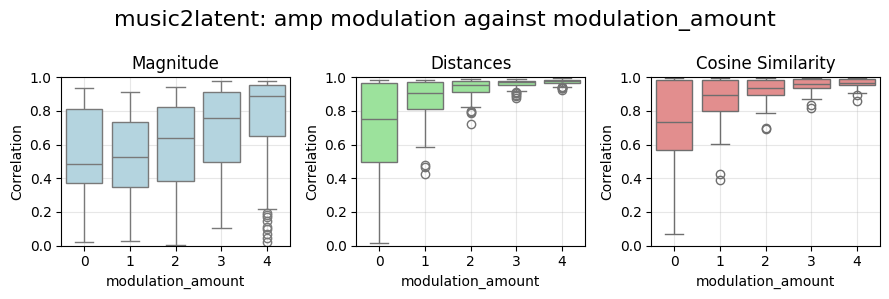

In [78]:

def plot_correlation_boxplots(df, repr, mod_target, x):
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))

    columns = [f'correlation_{repr}_magnitude', f'correlation_{repr}_distances', f'correlation_{repr}_cosine_similarity']
    colors = ['lightblue', 'lightgreen', 'lightcoral']
    titles = ['Magnitude', 'Distances', 'Cosine Similarity']

    index = 'base_freq amp filter_cutoff osc_shape'.split().index(mod_target)

    filtered_df = df[df['modulated_index'] == index]

    for i, (col, color, title) in enumerate(zip(columns, colors, titles)):
        sns.boxplot(data=filtered_df, x=x, y=col, ax=axes[i], color=color)
        axes[i].set_title(title)
        axes[i].set_ylim(0,1)
        axes[i].set_xlabel(x)
        axes[i].set_ylabel('Correlation')
        axes[i].grid(True, alpha=0.3)

    plt.suptitle(f'{repr}: {mod_target} modulation against {x}', fontsize=16)
    plt.tight_layout()
    plt.show()


# example
repr = 'music2latent'
MOD_TARGET = 'amp'
X = 'modulation_amount'


plot_correlation_boxplots(df, repr, MOD_TARGET, X)

Plotting for spectrum


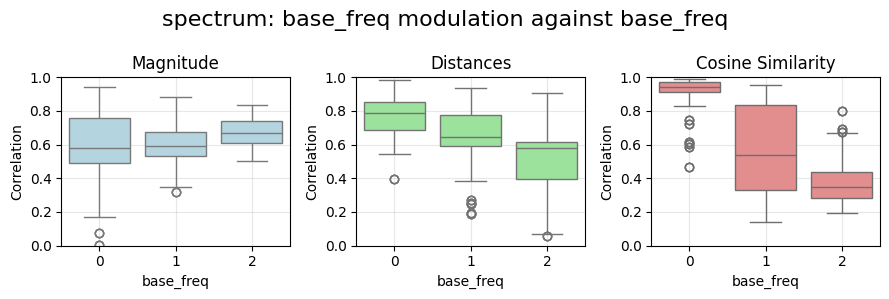

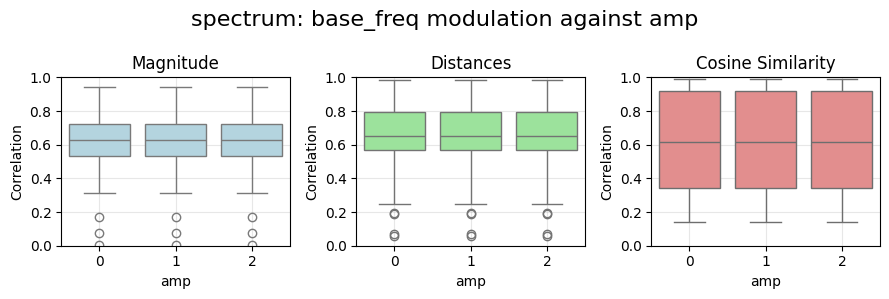

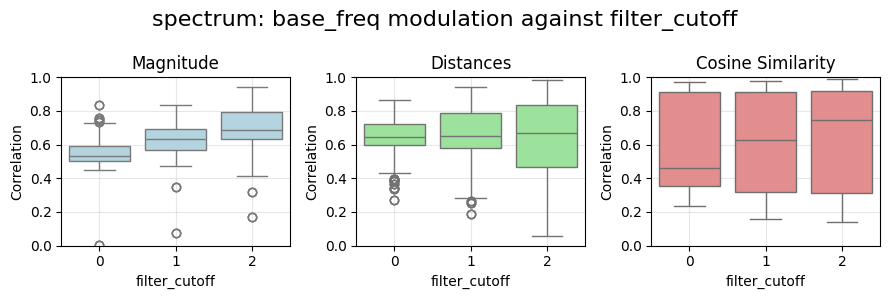

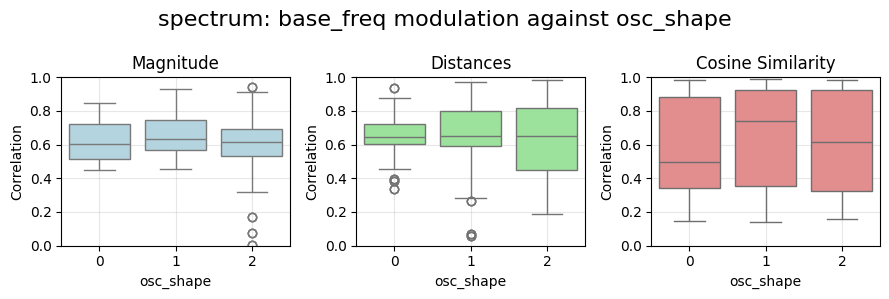

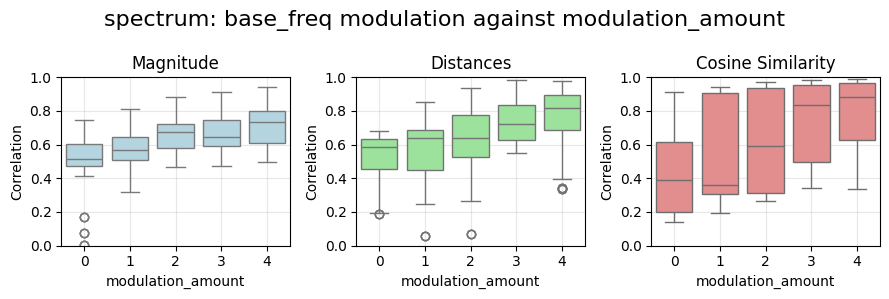

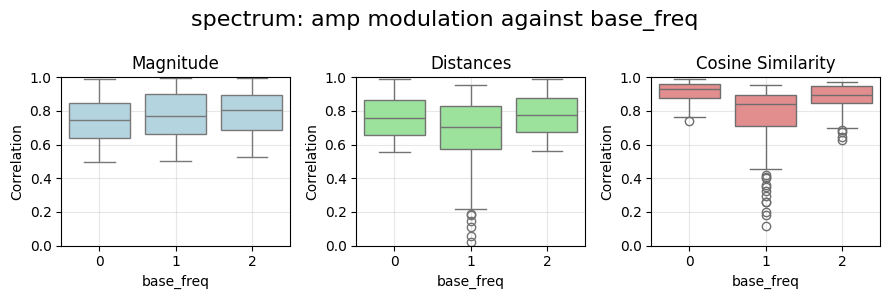

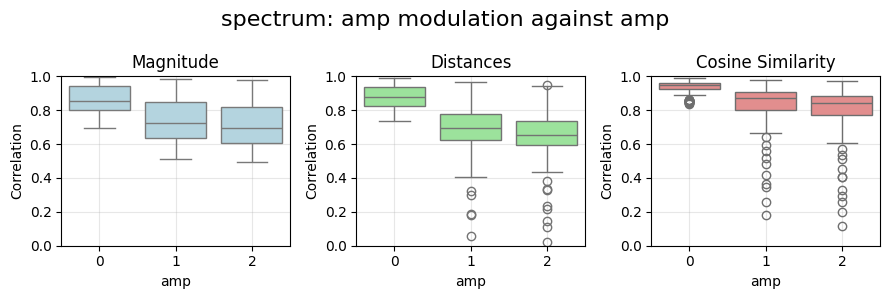

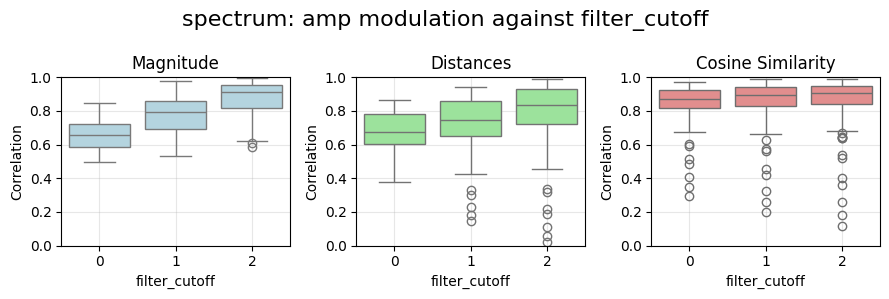

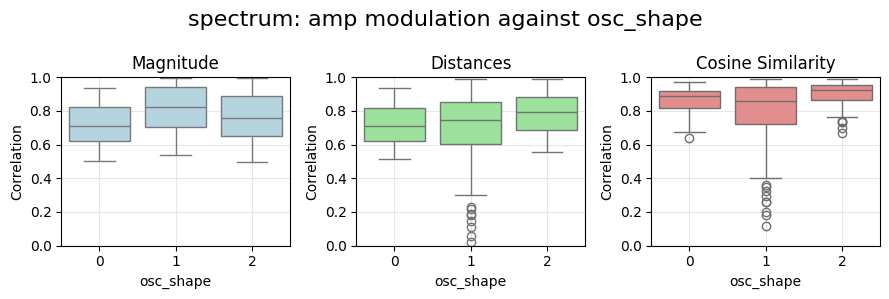

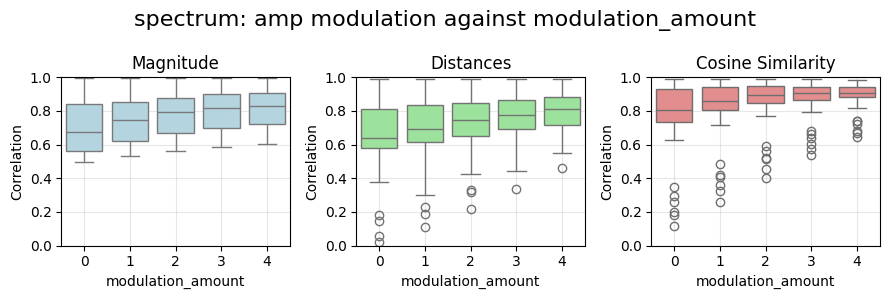

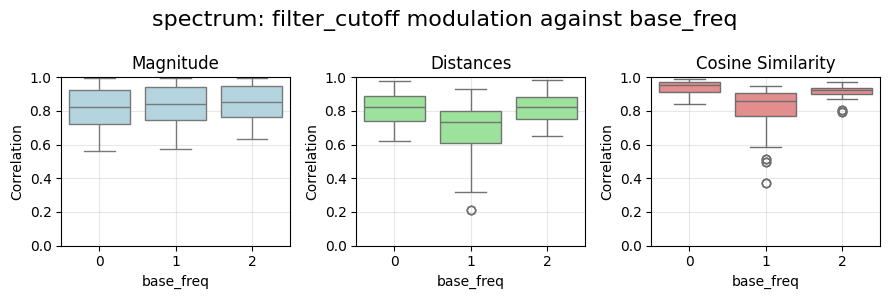

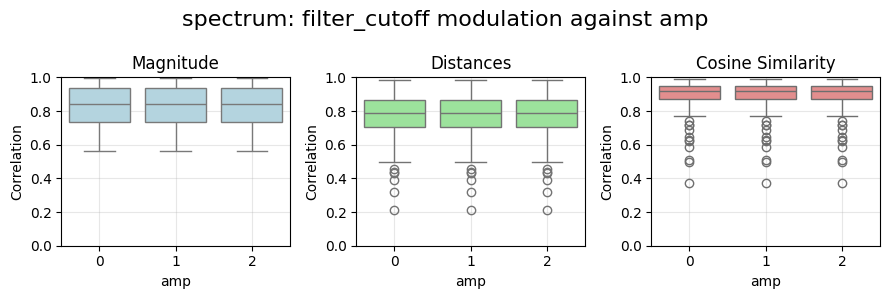

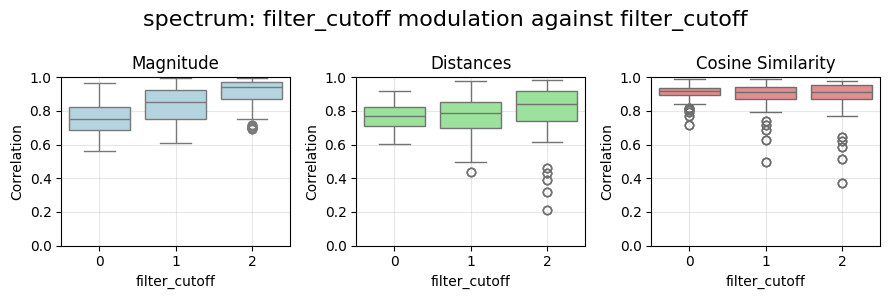

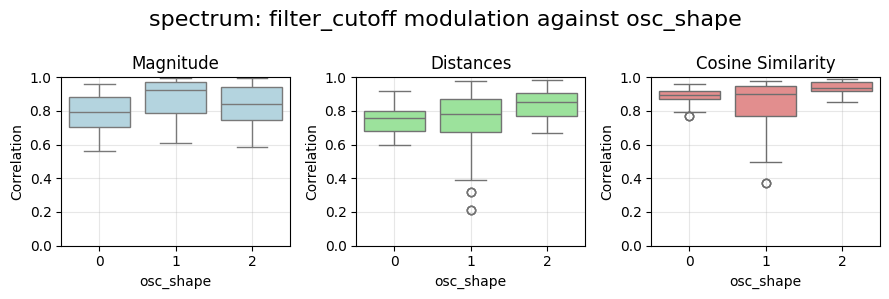

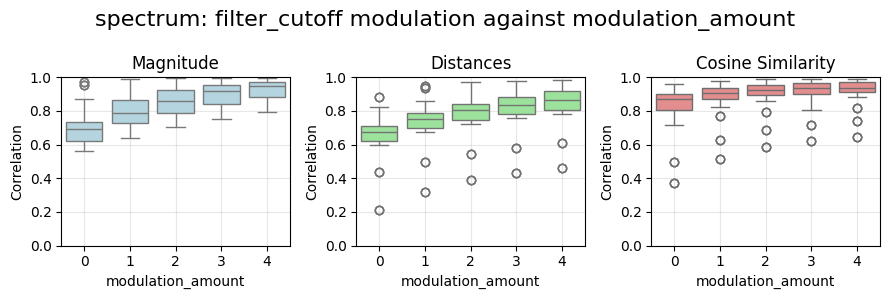

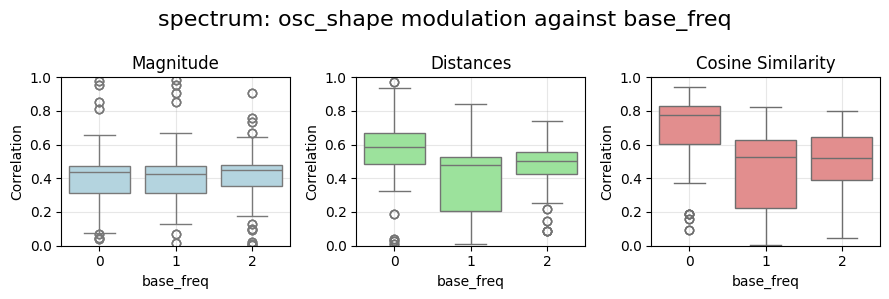

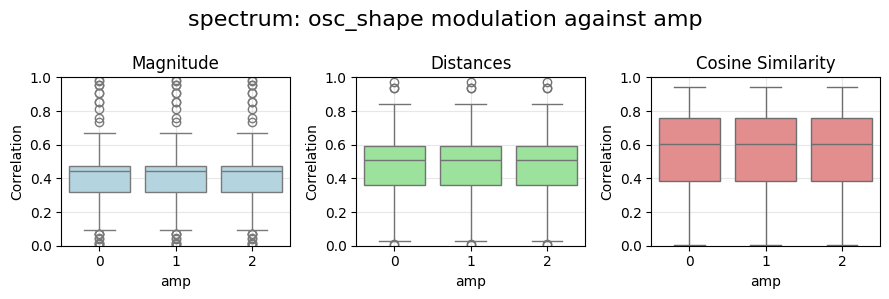

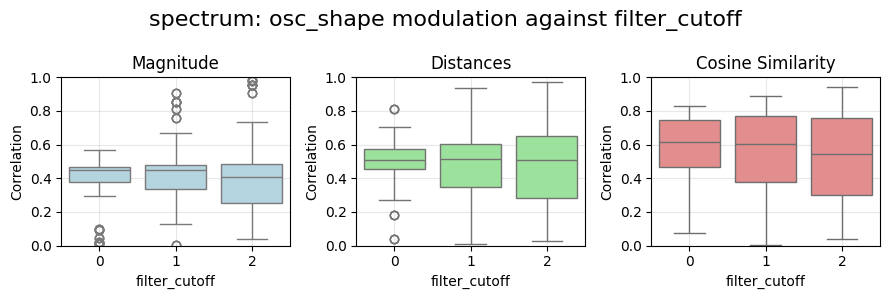

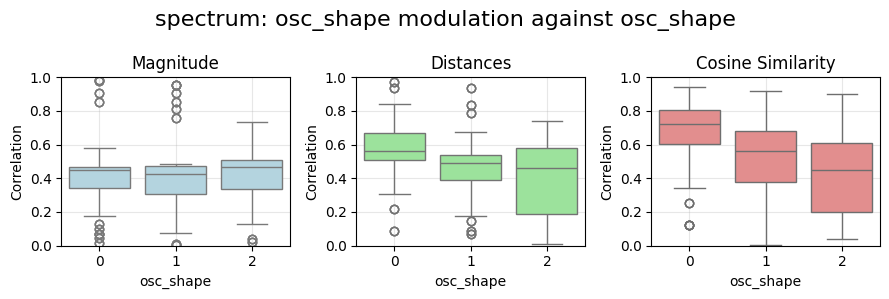

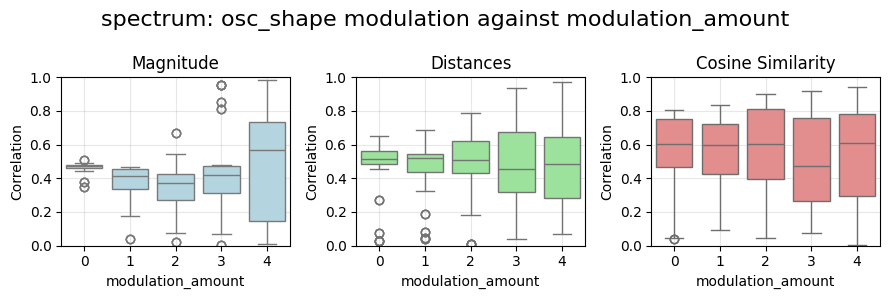

Plotting for dac


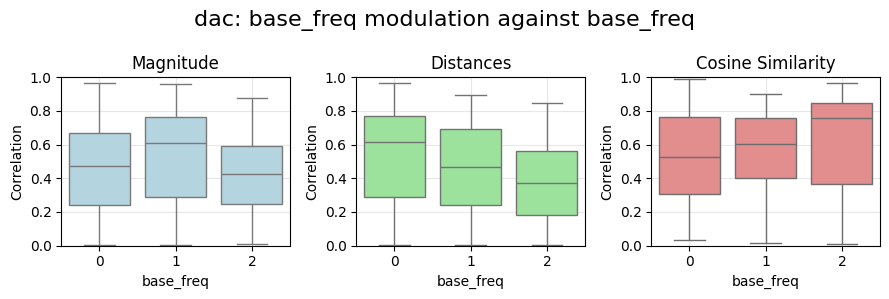

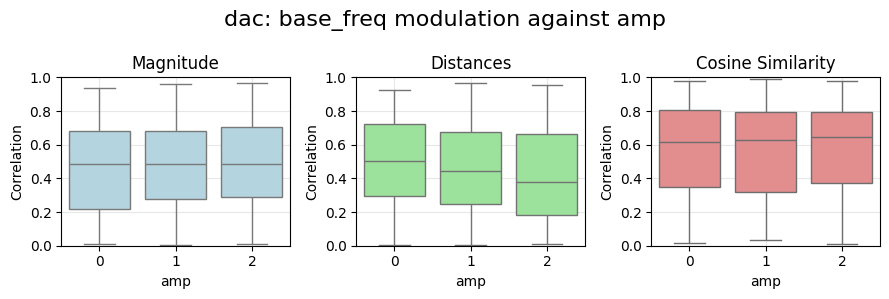

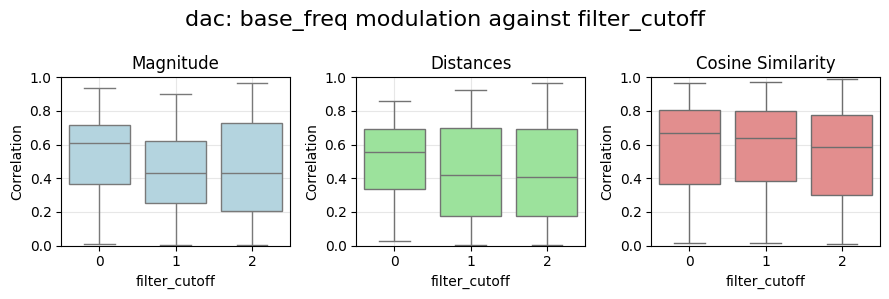

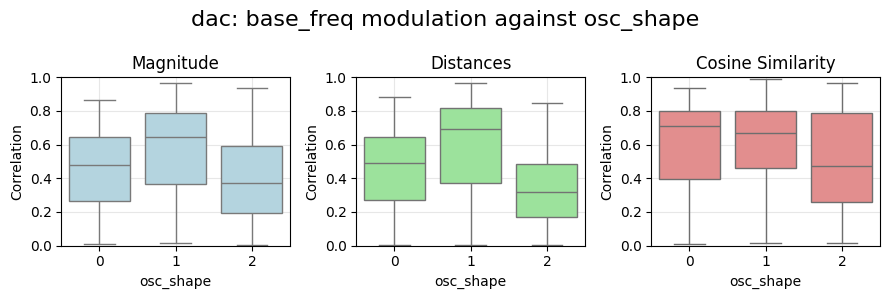

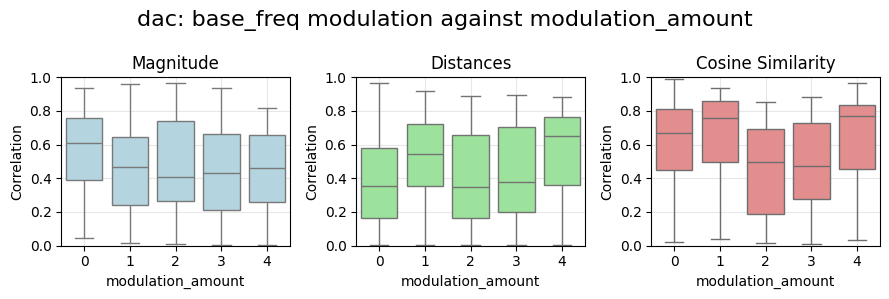

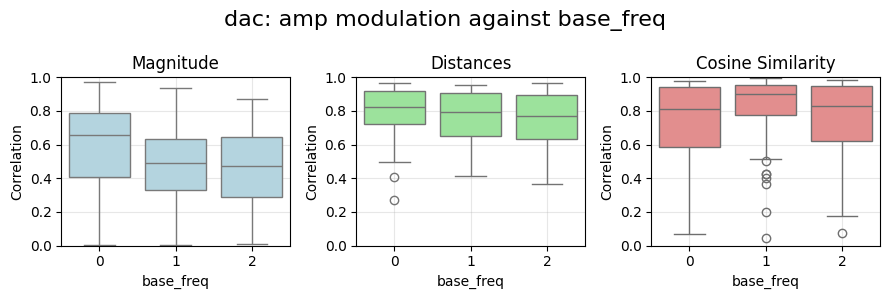

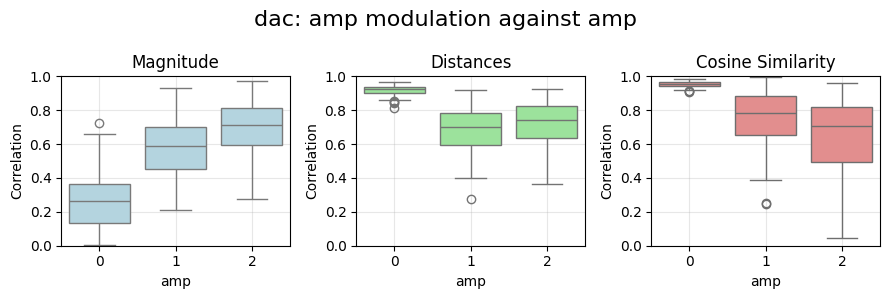

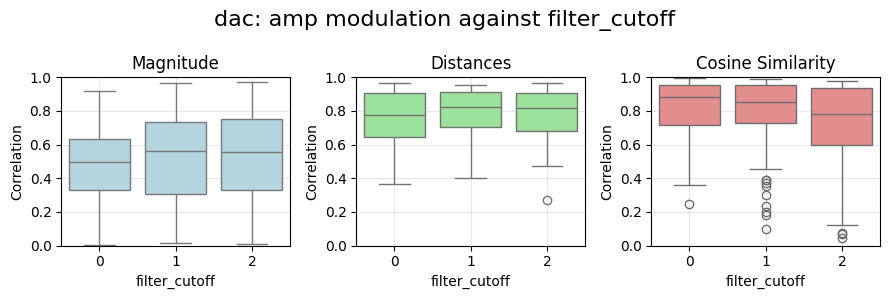

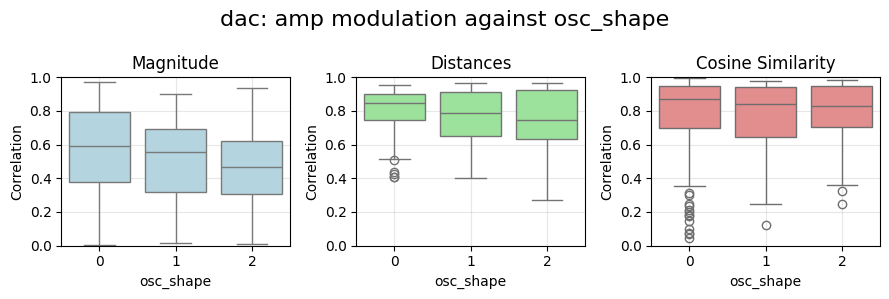

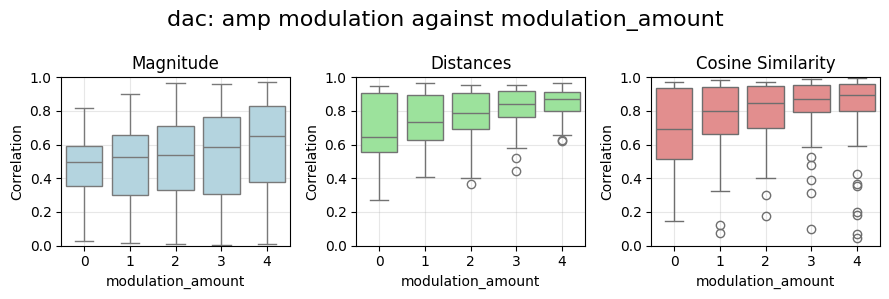

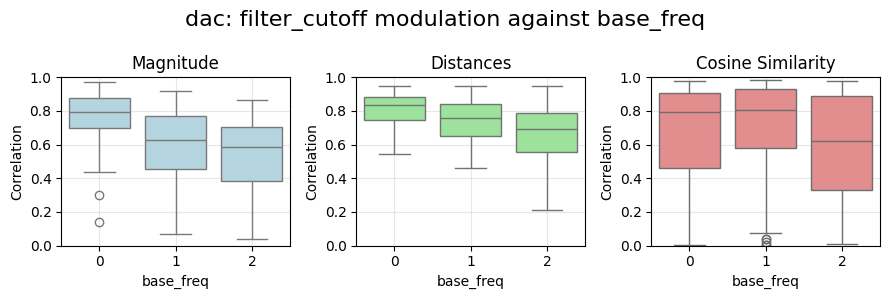

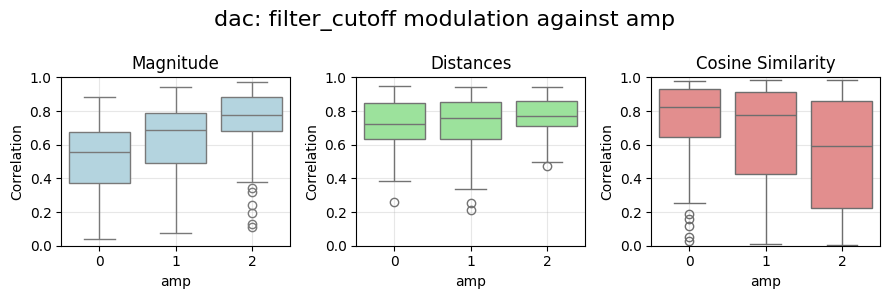

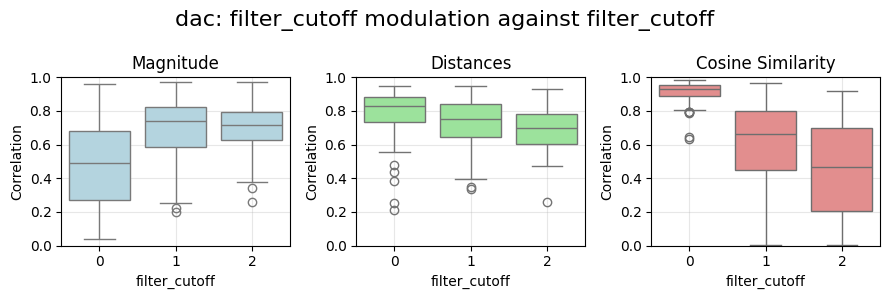

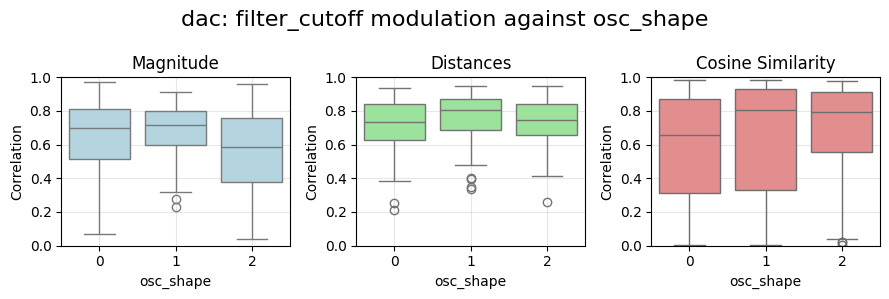

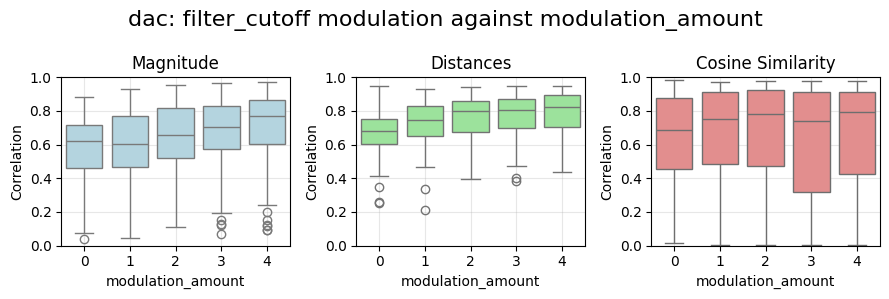

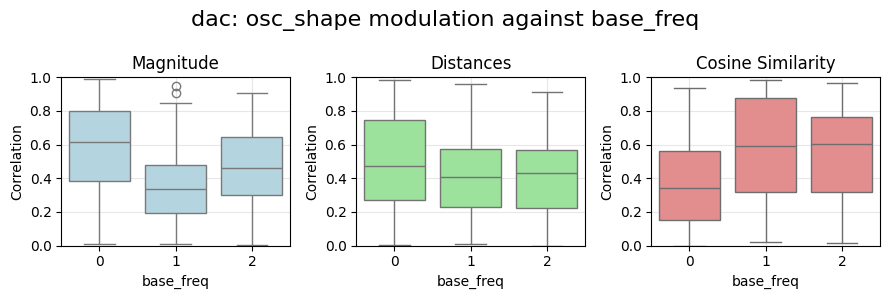

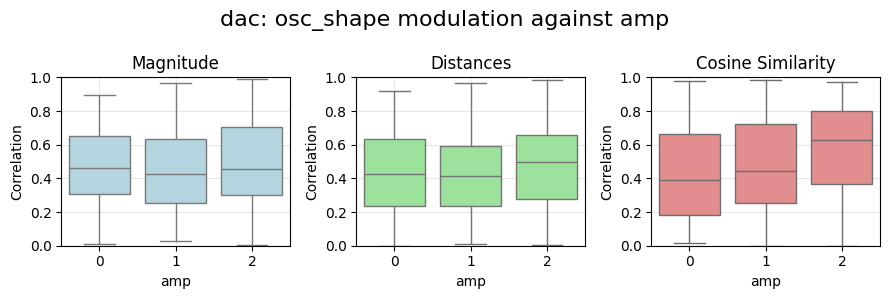

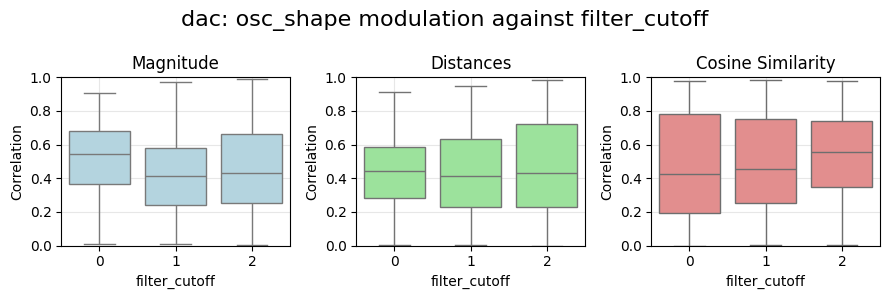

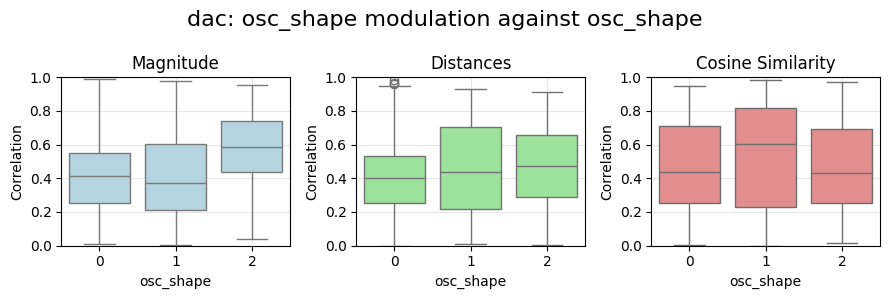

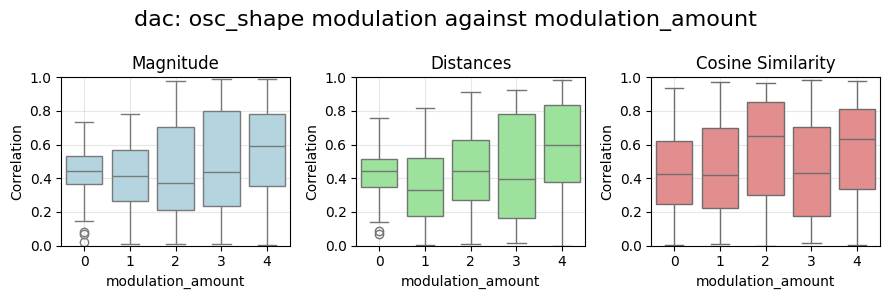

Plotting for music2latent


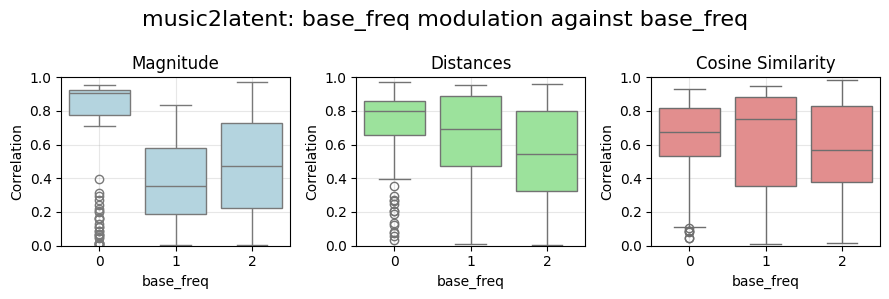

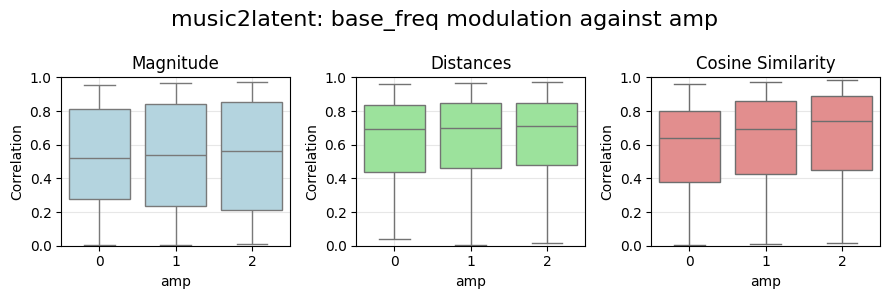

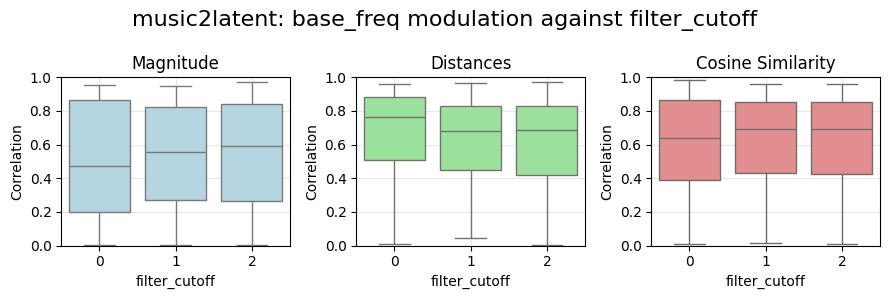

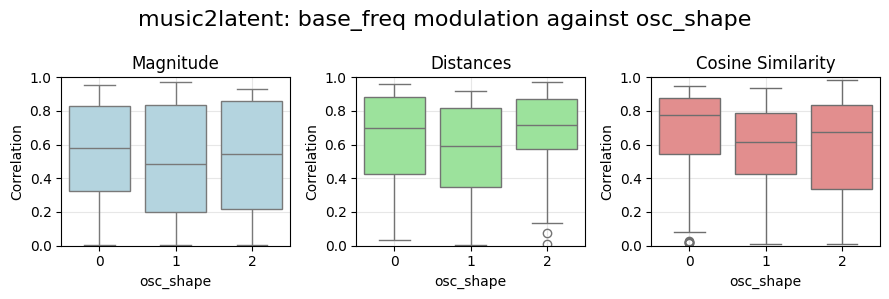

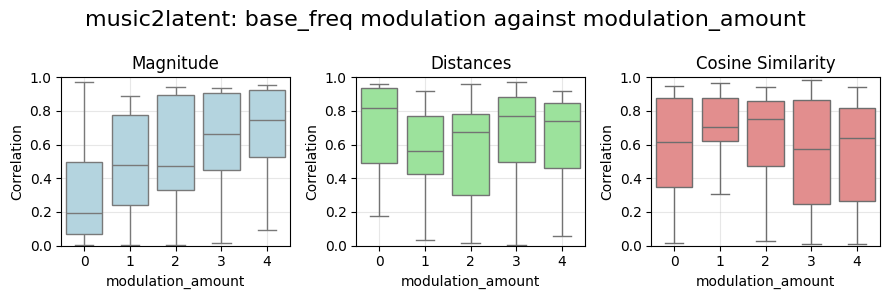

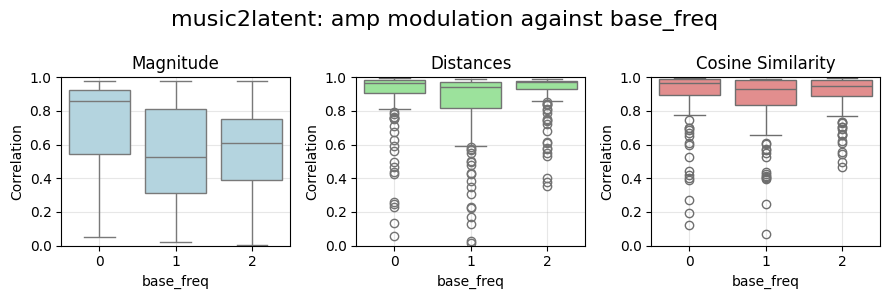

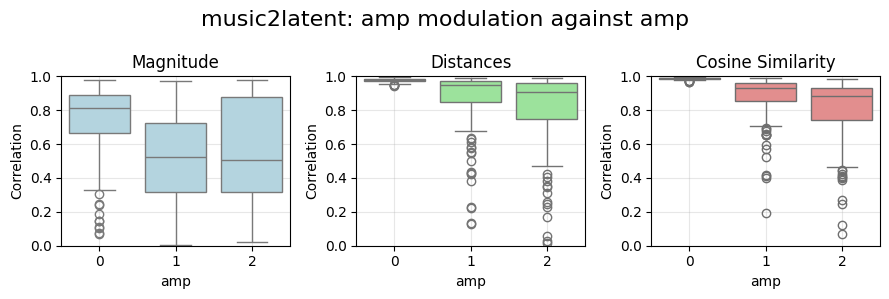

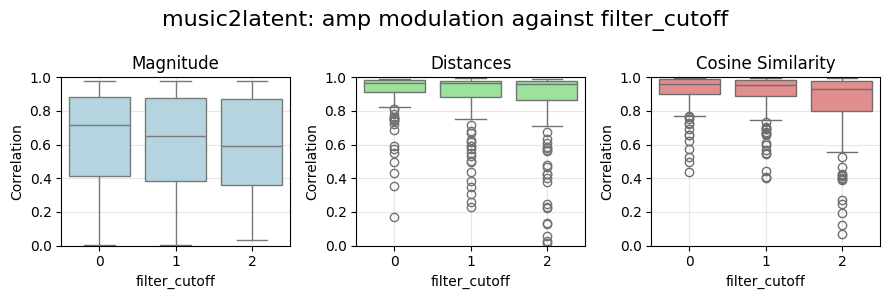

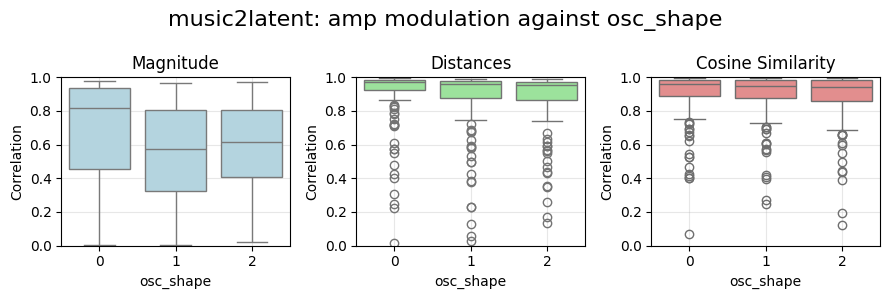

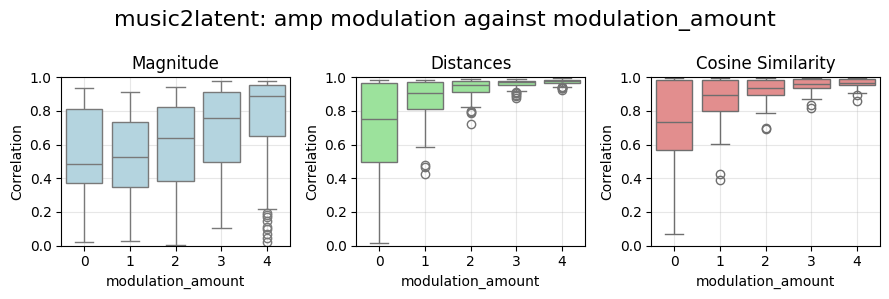

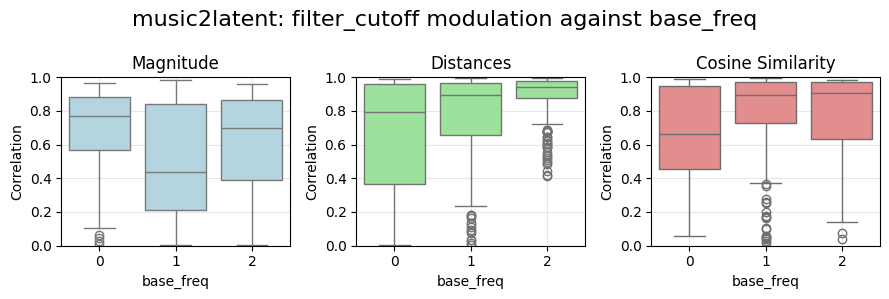

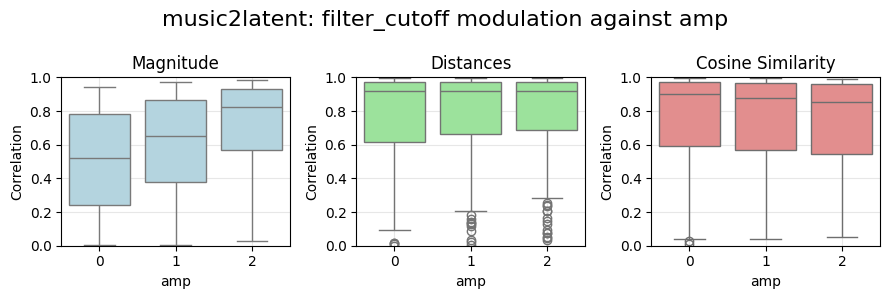

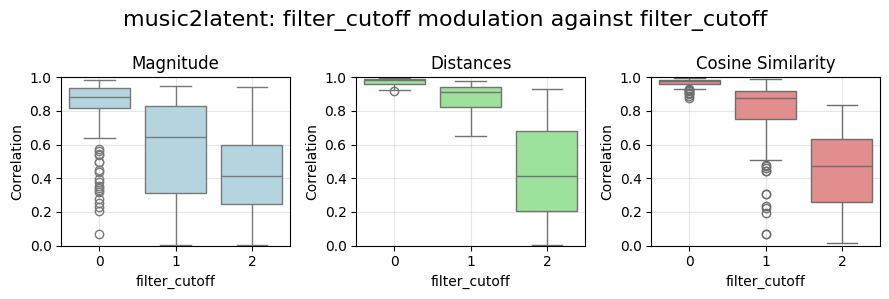

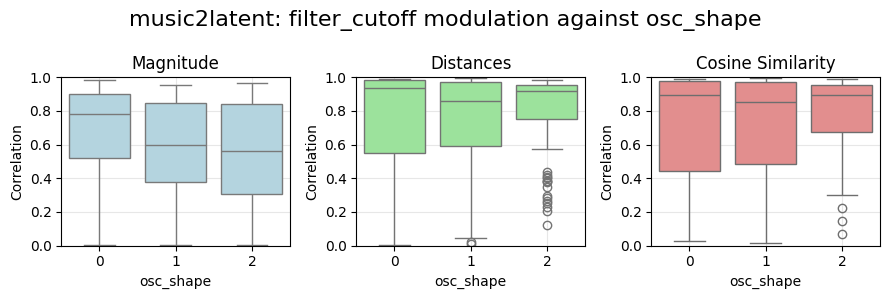

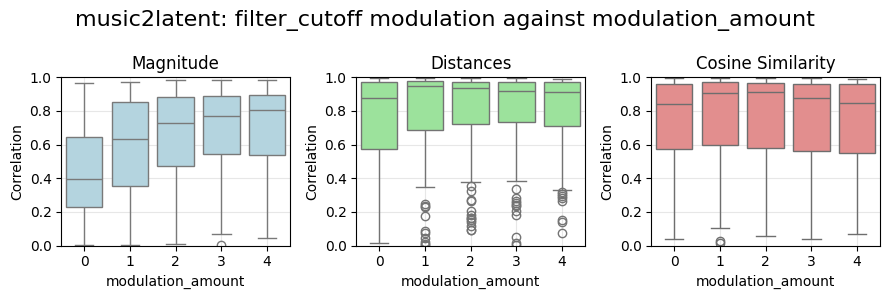

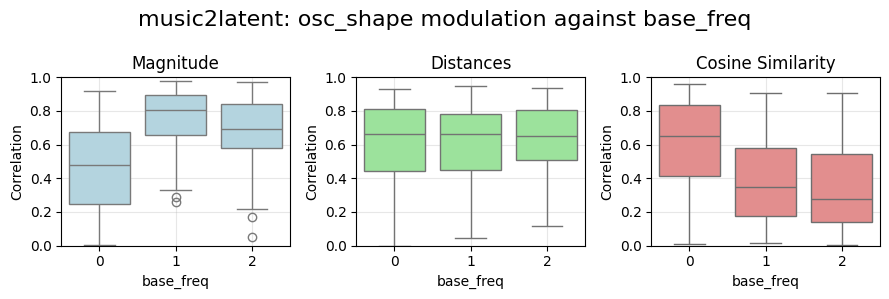

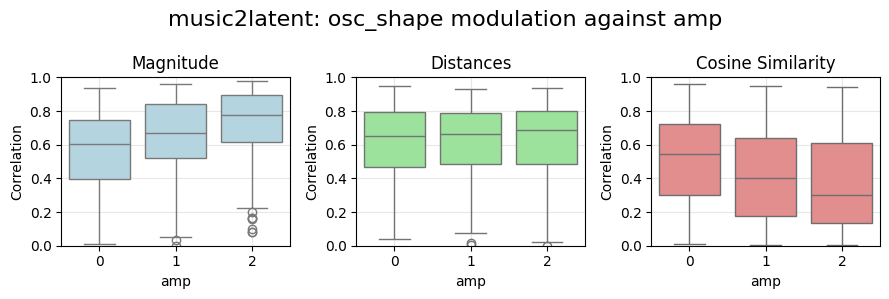

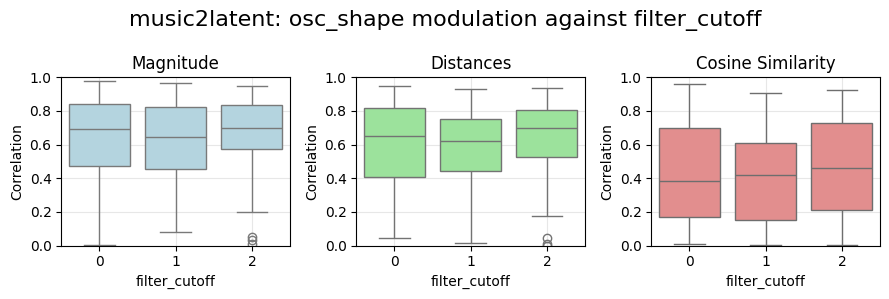

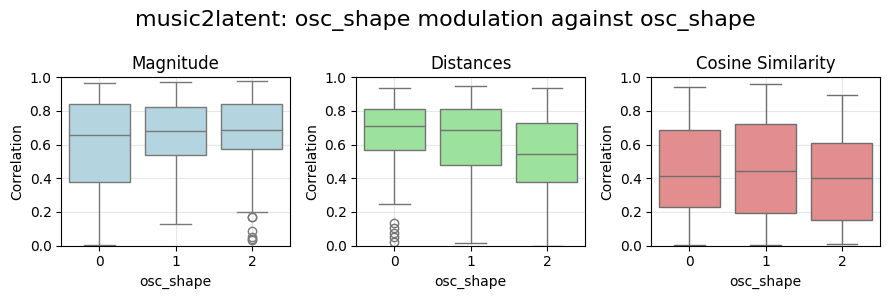

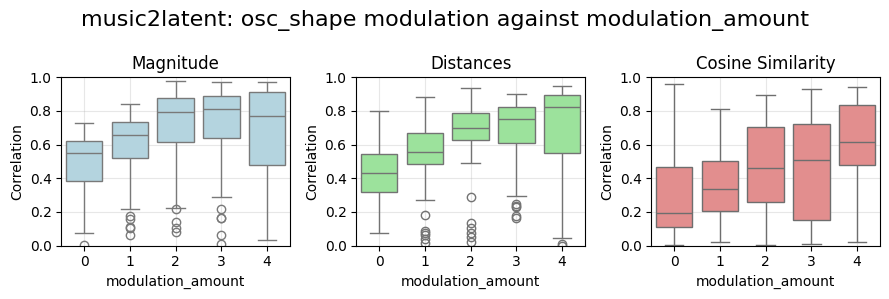

Plotting for cqt


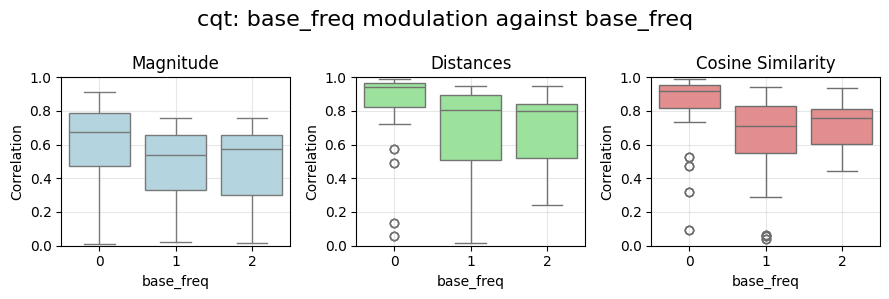

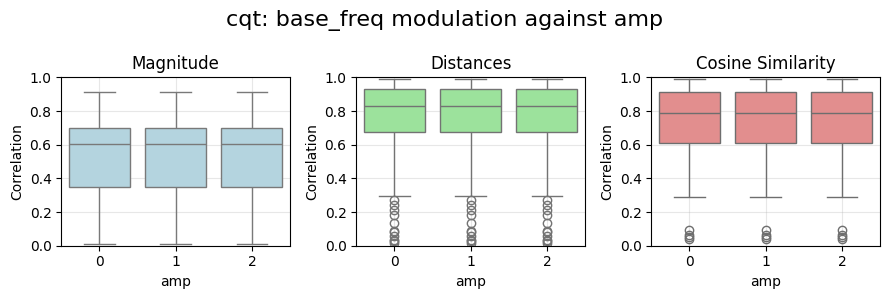

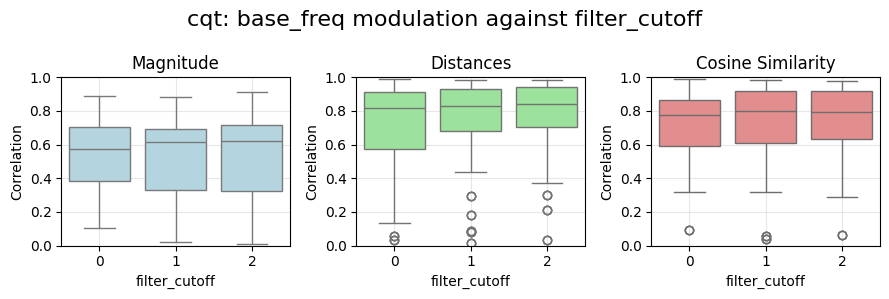

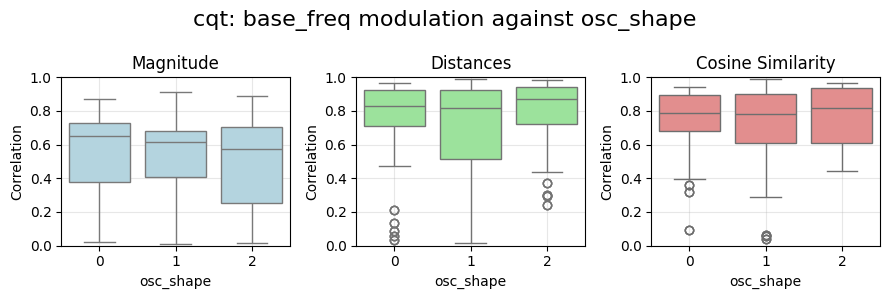

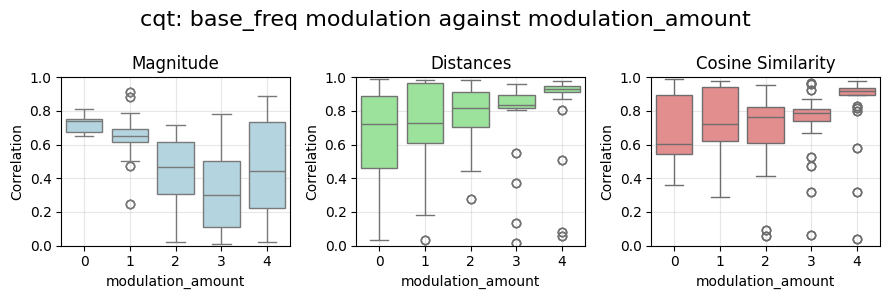

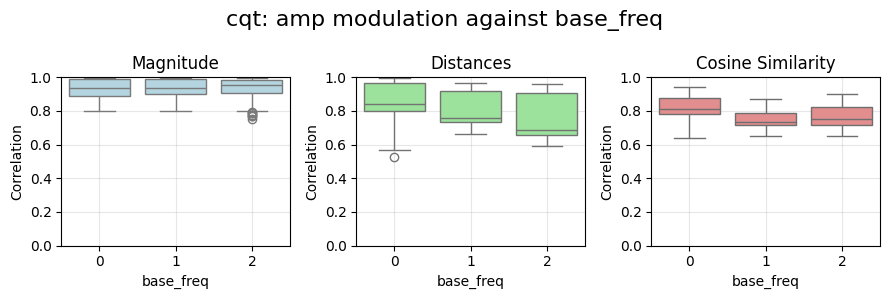

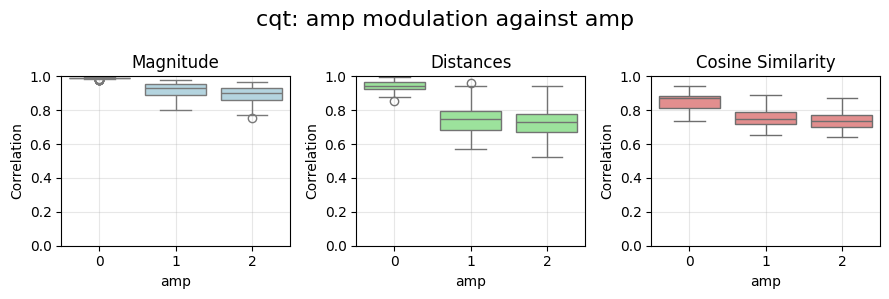

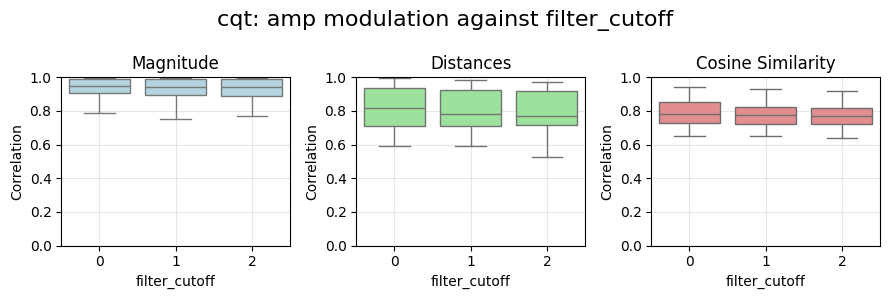

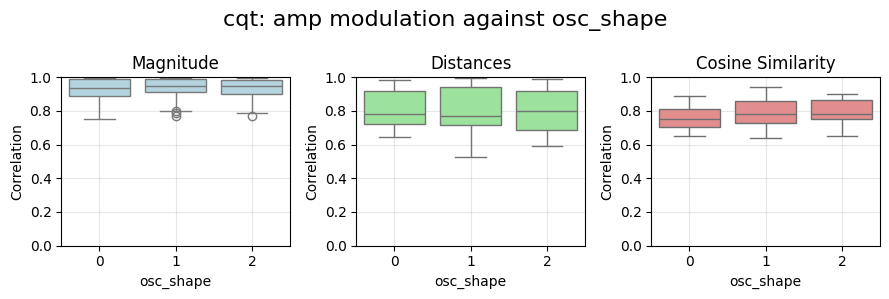

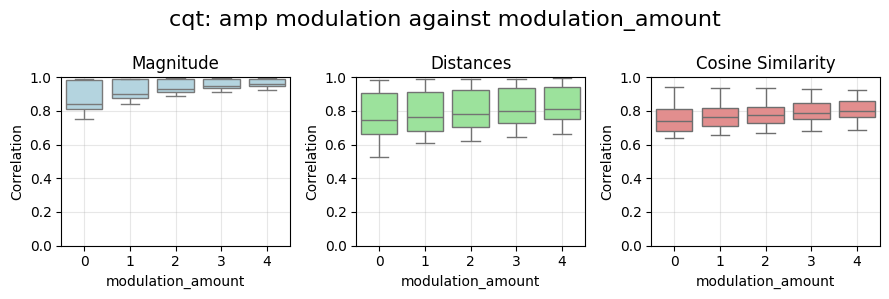

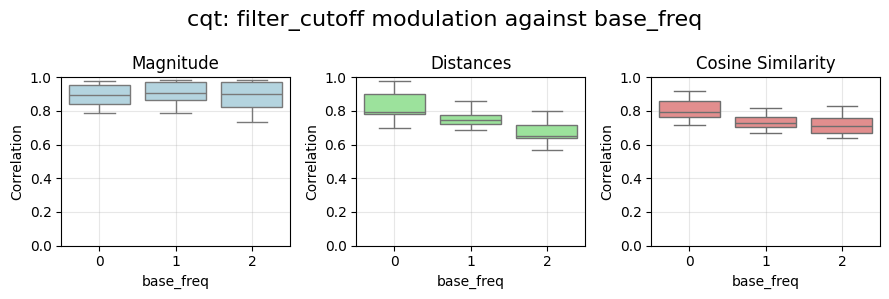

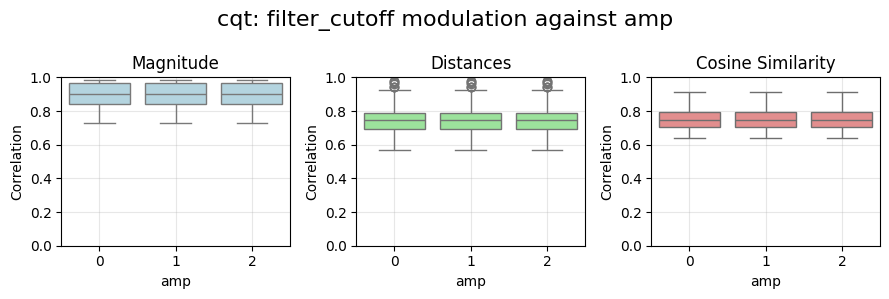

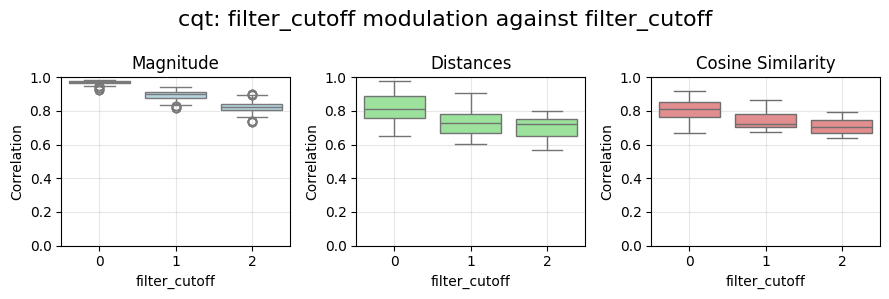

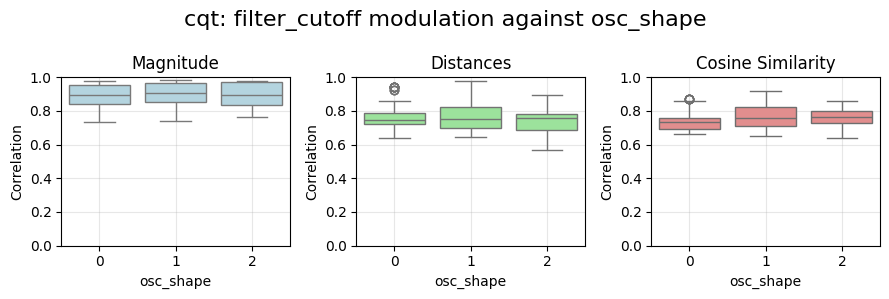

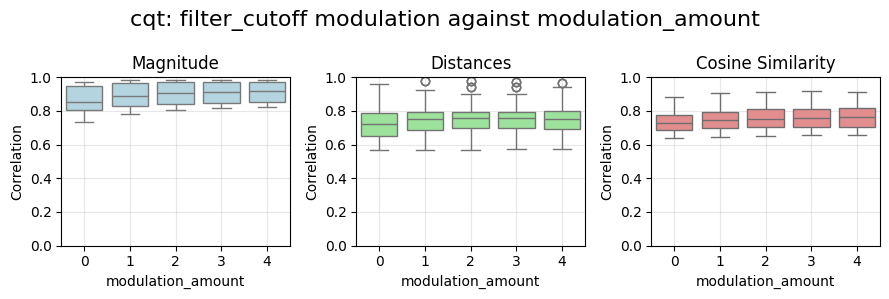

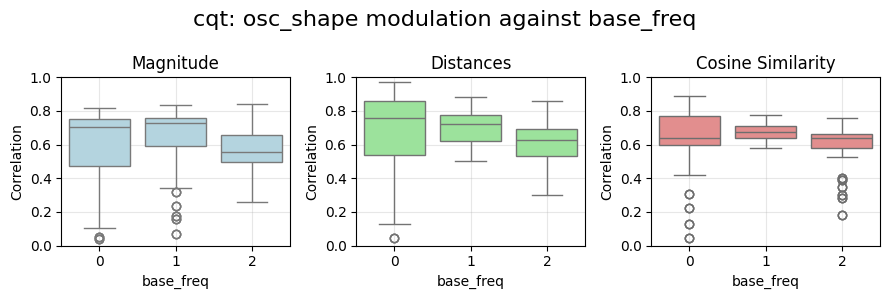

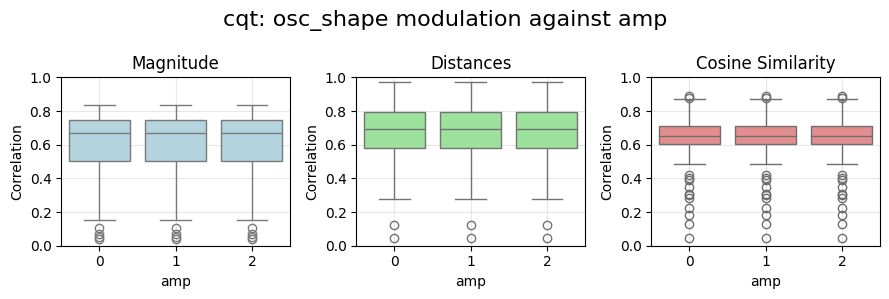

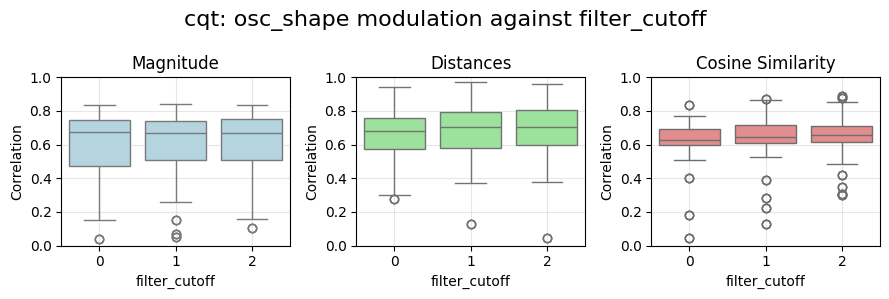

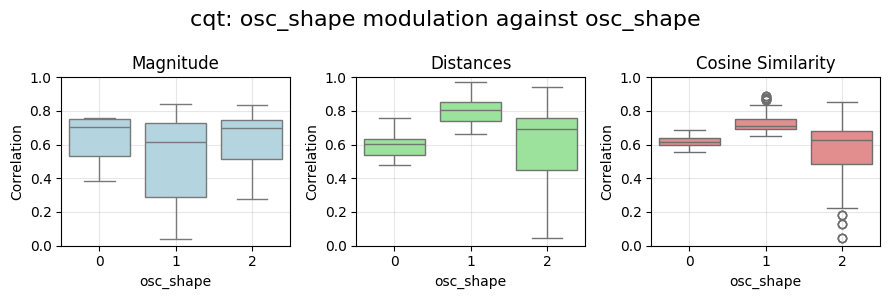

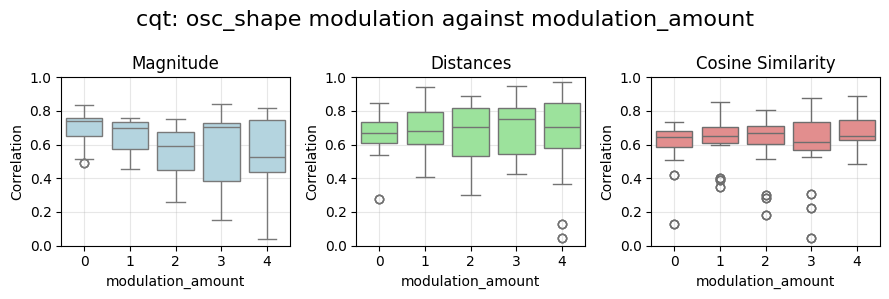

Plotting for mfcc


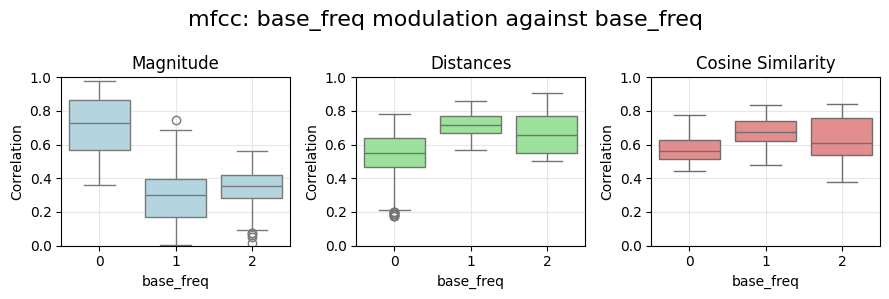

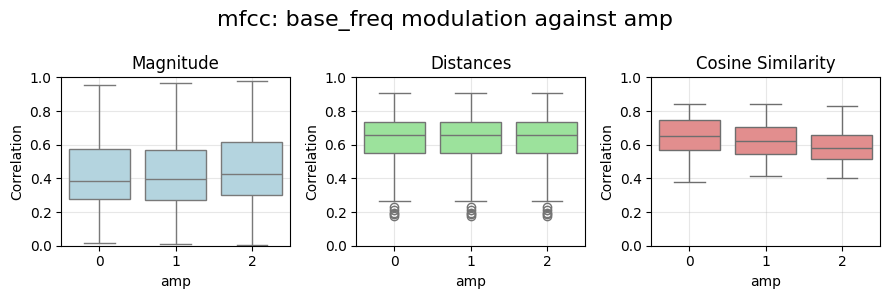

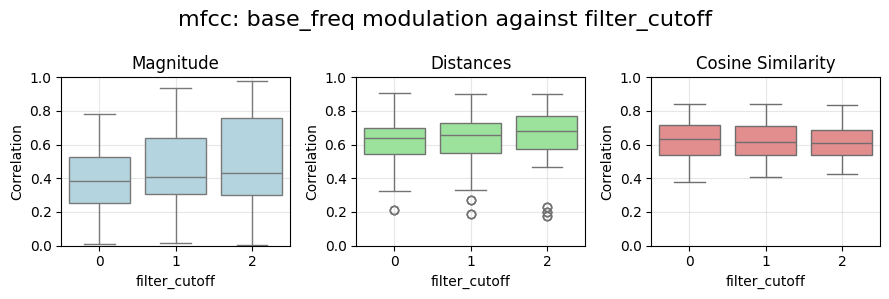

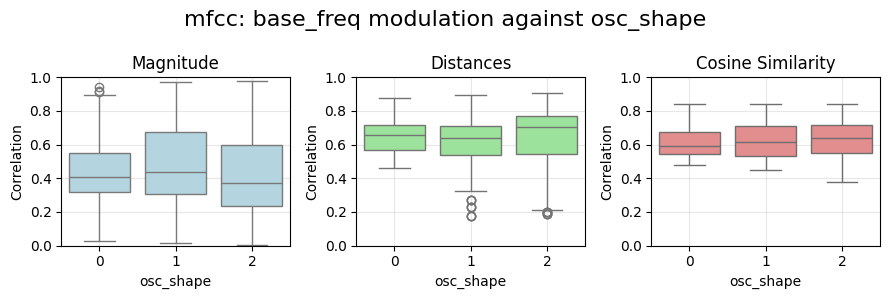

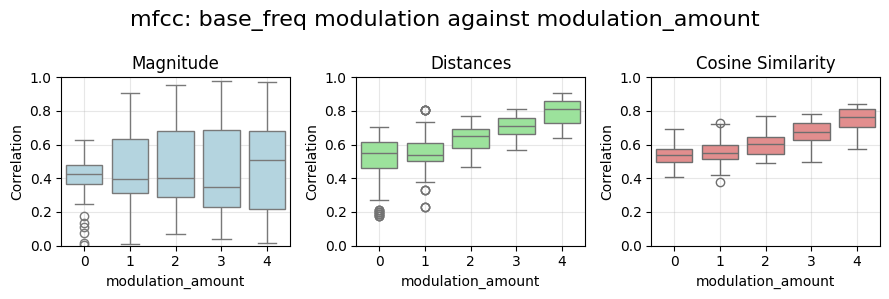

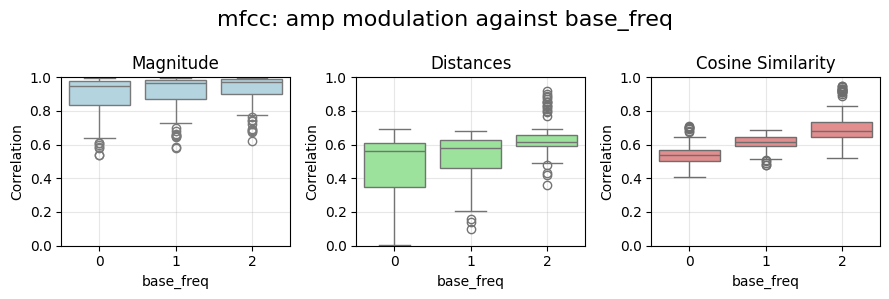

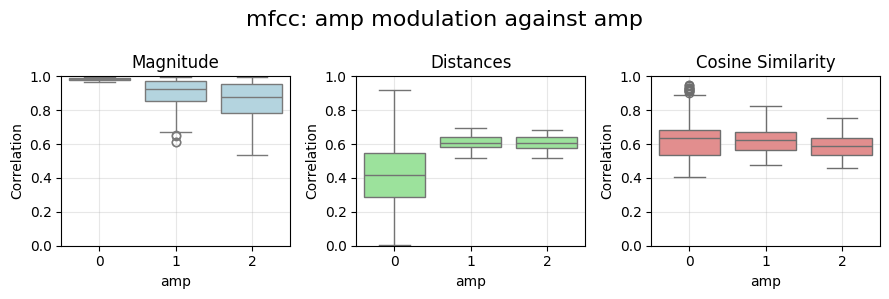

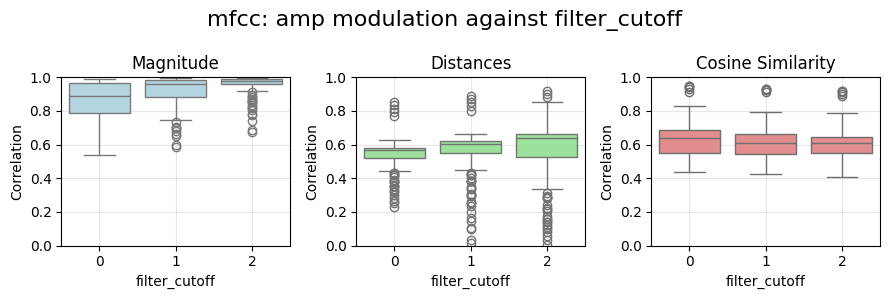

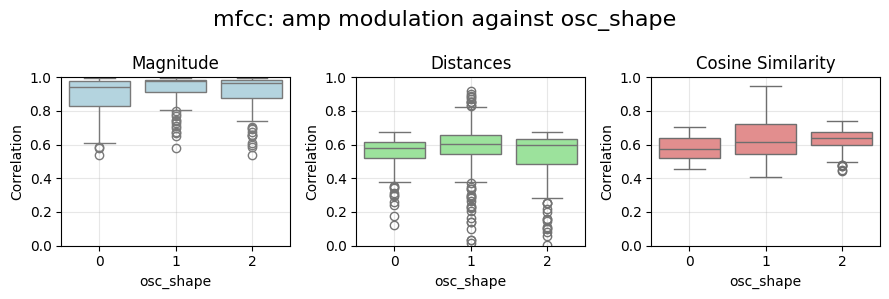

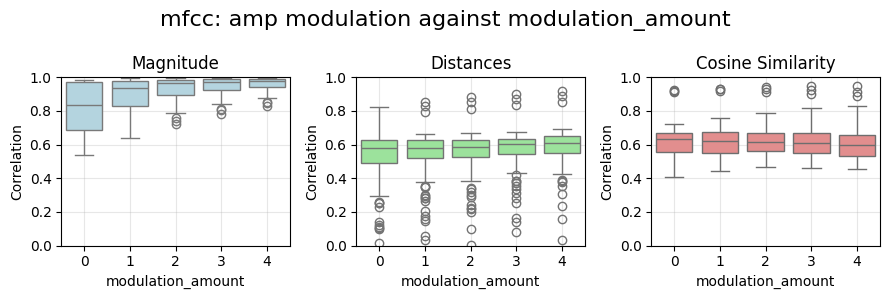

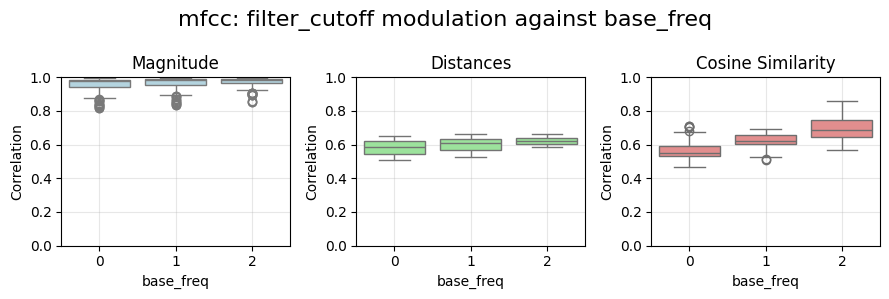

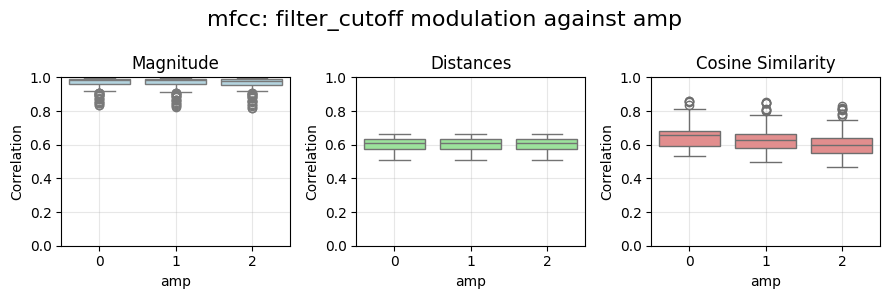

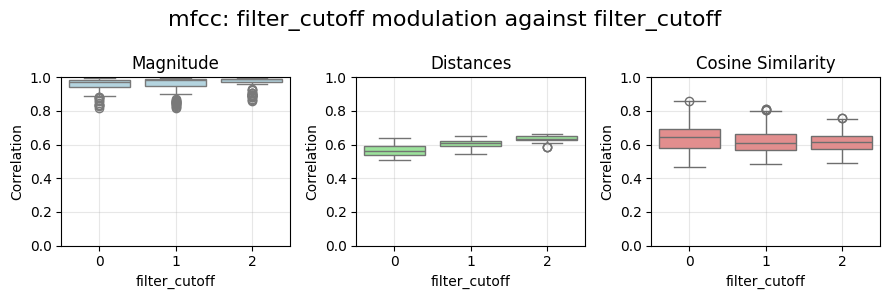

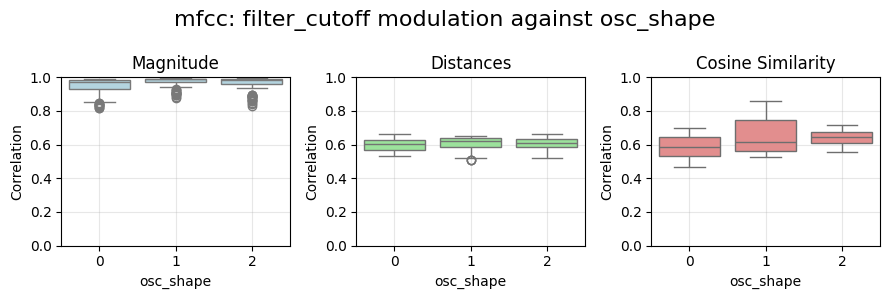

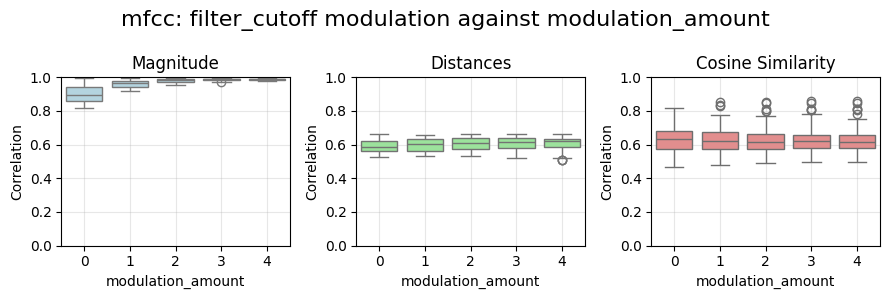

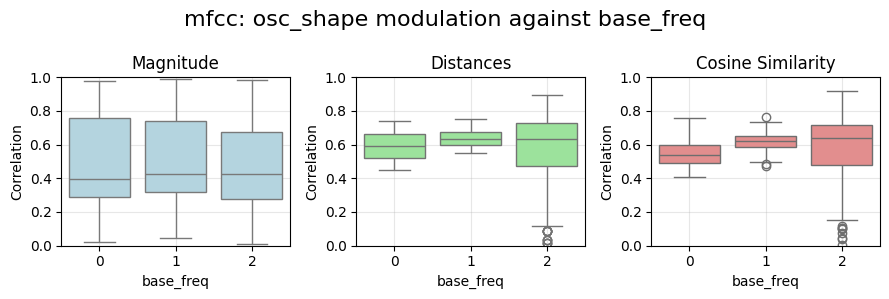

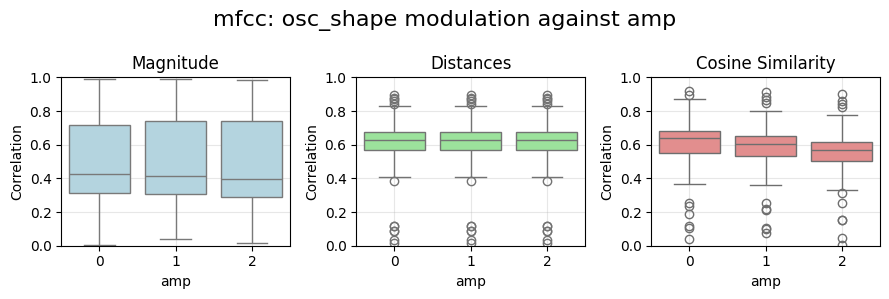

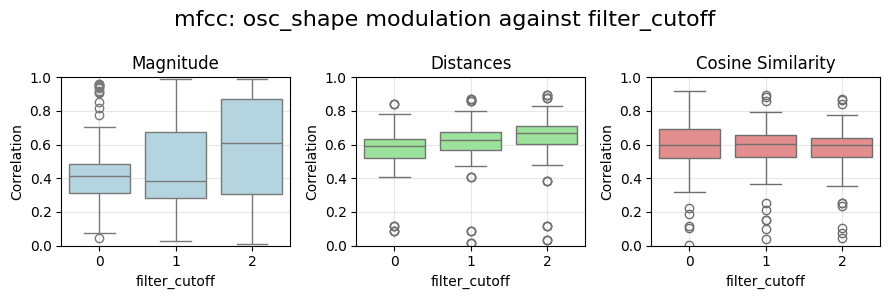

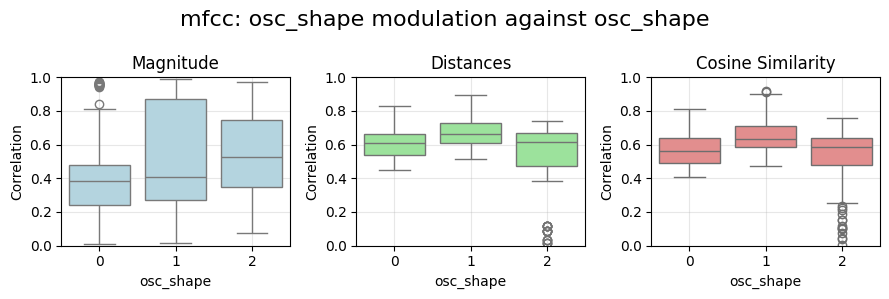

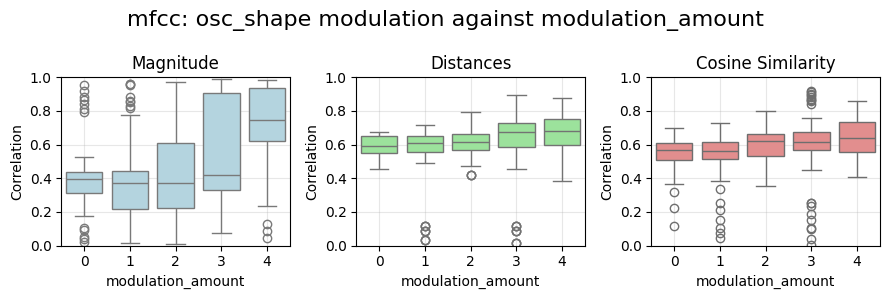

In [79]:
# plot all the possible combinations of repr, mod_target and x
reprs = 'spectrum dac music2latent cqt mfcc'.split()
mod_targets = 'base_freq amp filter_cutoff osc_shape'.split()
xs = 'base_freq amp filter_cutoff osc_shape modulation_amount'.split()

for repr in reprs:
    print(f'Plotting for {repr}')
    for mod_target in mod_targets:
        for x in xs:
            plot_correlation_boxplots(df, repr, mod_target, x)

